# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

In [12]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 

PATHIM = "cnd_large//cnd_large//images.csv" 
PATHLB = "cnd_large//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


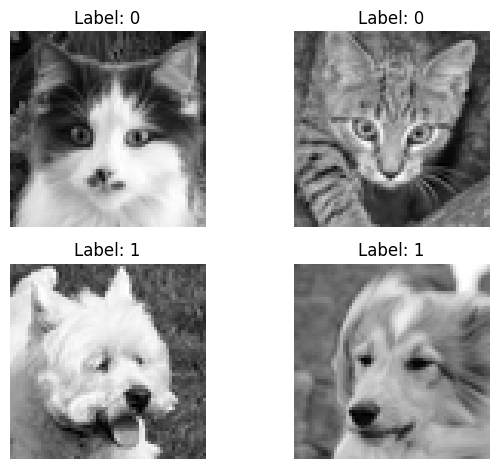

In [13]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [14]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = images
y = labels

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_train_full = X_train_full.shape[0]
fractions = np.linspace(1.0, 0.1, 10)

results = { "svd": [], "shrink": [] }
rng = np.random.RandomState(0)

for f in fractions:
    n_keep = int(n_train_full * f)
    idx = rng.choice(n_train_full, n_keep, replace=False)
    X_train = X_train_full[idx]
    y_train = y_train_full[idx]

    # SVD solver (fastest)
    try:
        acc_svd = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train).predict(X_test)
        )
    except:
        acc_svd = np.nan

    # Regularized / shrunk LDA (fast, avoids singularity)
    try:
        acc_shrink = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
            .fit(X_train, y_train)
            .predict(X_test)
        )
    except:
        acc_shrink = np.nan

    results["svd"].append((f, acc_svd))
    results["shrink"].append((f, acc_shrink))

# Print
for name in results:
    print(f"\n== {name} ==")
    for f, acc in results[name]:
        print(f"Fraction {f:.2f}: acc = {acc:.3f}")


== svd ==
Fraction 1.00: acc = 0.689
Fraction 0.90: acc = 0.670
Fraction 0.80: acc = 0.648
Fraction 0.70: acc = 0.606
Fraction 0.60: acc = 0.545
Fraction 0.50: acc = 0.599
Fraction 0.40: acc = 0.660
Fraction 0.30: acc = 0.674
Fraction 0.20: acc = 0.723
Fraction 0.10: acc = 0.738

== shrink ==
Fraction 1.00: acc = 0.756
Fraction 0.90: acc = 0.746
Fraction 0.80: acc = 0.745
Fraction 0.70: acc = 0.747
Fraction 0.60: acc = 0.733
Fraction 0.50: acc = 0.728
Fraction 0.40: acc = 0.729
Fraction 0.30: acc = 0.710
Fraction 0.20: acc = 0.726
Fraction 0.10: acc = 0.730


# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



In [15]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

X = np.asarray(images, dtype=float) / 255.0
y = np.asarray(labels).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Threshold of importance
Using Anova F-test to select number of features that is optimal from K_grid

In [16]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
K_GRID = [10, 50, 200, 500, 800, 1000, 1200, 1500, 2000]
def cv_select_k(X_train, y_train, seed=0):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    out = {}
    classifiers = [
        ("LDA", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ("LinearSVM", LinearSVC(C=1.0, dual=False, max_iter=1000, tol=1e-3, random_state=seed)),
        ("XGBoost", XGBClassifier(n_jobs=-1, random_state=seed)),
    ]
    for name, clf in classifiers:
        accs = []
        for K in K_GRID:
            print(f"Processing {name} {K}...")
            pipe = Pipeline([
                ("scale", StandardScaler()),
                ("sel", SelectKBest(score_func=f_classif, k=K)),
                ("clf", clf),
            ])
            s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
            accs.append(s.mean())
        accs = np.array(accs)
        best_k_value = K_GRID[int(np.argmax(accs))]
        sel = SelectKBest(score_func=f_classif, k=best_k_value).fit(X_train, y_train)
        print(f"  Best K = {best_k_value}, CV acc = {accs.max():.3f}")
        out[name] = {"K_grid": list(K_GRID), "cv_acc": accs,
                     "K_best": best_k_value, "mask": sel.get_support()}
        print(f"{name:7s} | K_best = {out[name]['K_best']:5d} | best CV acc = {out[name]['cv_acc'].max():.3f}")
    return out


Processing LDA 10...
Processing LDA 50...
Processing LDA 200...
Processing LDA 500...
Processing LDA 800...
Processing LDA 1000...
Processing LDA 1200...
Processing LDA 1500...
Processing LDA 2000...
  Best K = 1000, CV acc = 0.769
LDA     | K_best =  1000 | best CV acc = 0.769
Processing LinearSVM 10...
Processing LinearSVM 50...
Processing LinearSVM 200...
Processing LinearSVM 500...
Processing LinearSVM 800...
Processing LinearSVM 1000...
Processing LinearSVM 1200...
Processing LinearSVM 1500...
Processing LinearSVM 2000...
  Best K = 1000, CV acc = 0.751
LinearSVM | K_best =  1000 | best CV acc = 0.751
Processing XGBoost 10...
Processing XGBoost 50...
Processing XGBoost 200...
Processing XGBoost 500...
Processing XGBoost 800...
Processing XGBoost 1000...
Processing XGBoost 1200...
Processing XGBoost 1500...
Processing XGBoost 2000...
  Best K = 1500, CV acc = 0.895
XGBoost | K_best =  1500 | best CV acc = 0.895


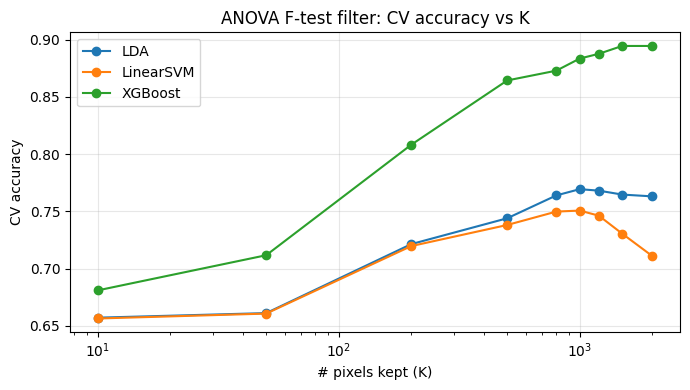

In [18]:
seed = 0
filter_res = cv_select_k(X_train, y_train, seed=seed)

fig, ax = plt.subplots(figsize=(7, 4))
for name, r in filter_res.items():
    ax.plot(r["K_grid"], r["cv_acc"], marker="o", label=name)
ax.set_xscale("log")
ax.set_xlabel("# pixels kept (K)")
ax.set_ylabel("CV accuracy")
ax.set_title("ANOVA F-test filter: CV accuracy vs K")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


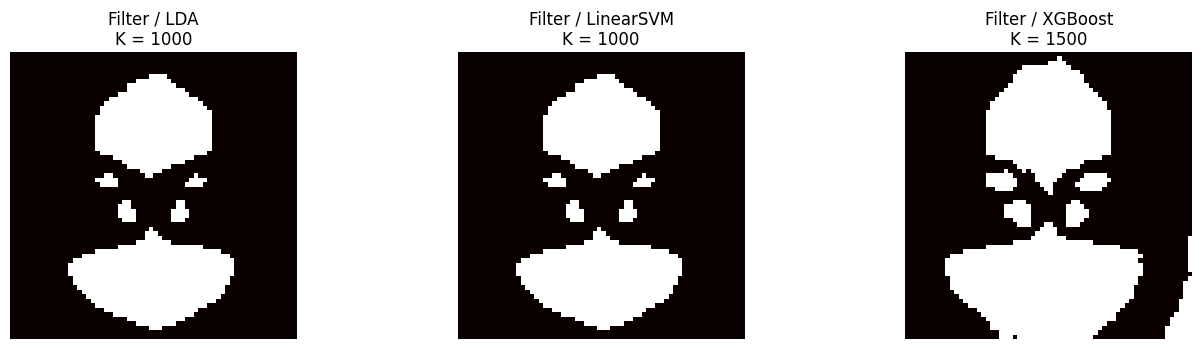

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (name, r) in zip(axes[:3], filter_res.items()):
    ax.imshow(r["mask"].reshape(64, 64), cmap="hot")
    ax.set_title(f"Filter / {name}\nK = {r['K_best']}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Selection with embedded
Uses l1 logistic regression to select pixels to use for out methods

In [20]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
def cv_lasso_embedded_fs(X, y, seed=0):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000
    )
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    lasso.fit(X_scaled, y)
    selector = SelectFromModel(
        lasso,
        prefit=True
    )
    X_selected = selector.transform(X_scaled)
    selected_pixels = selector.get_support(indices=True)
    print("Number of selected pixels:", len(selected_pixels))
    classifiers = [
        ("LDA", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ("LinearSVM", LinearSVC(C=1.0, dual=False, max_iter=1000, tol=1e-3, random_state=seed)),
        ("XGBoost", XGBClassifier(n_jobs=1, random_state=seed)),
    ]
    out = {}

    for name, clf in classifiers:
        print(f"Processing {name}...")
        scores = cross_val_score(clf, X_selected, y, cv=cv, scoring='accuracy', n_jobs=1)
        out[name] = {
            "cv_acc": scores.mean(),
        }

    return out, selected_pixels

In [21]:

seed = 0

embed_res, selected_pixels = cv_lasso_embedded_fs(X_train, y_train, seed=seed)

print("CV accuracy on the L1-selected pixels:")
for k, v in embed_res.items():
    print(f"{k:12s}:{v['cv_acc']:.3f}")

Number of selected pixels: 2210
Processing LDA...
Processing LinearSVM...
Processing XGBoost...
CV accuracy on the L1-selected pixels:
LDA         :0.799
LinearSVM   :0.797
XGBoost     :0.896


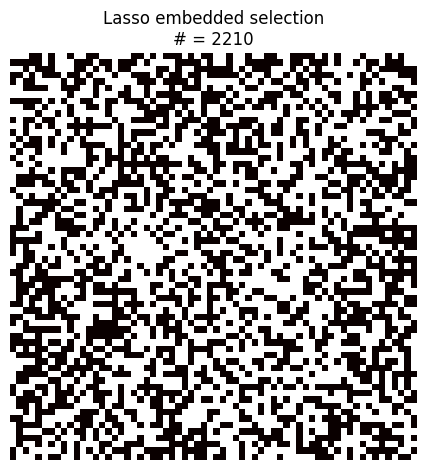

In [22]:
selected_pixels_image = np.zeros(X.shape[1])
selected_pixels_image[selected_pixels] = 1
plt.imshow(selected_pixels_image.reshape(64, 64), cmap="hot")
plt.title(f"Lasso embedded selection\n# = {len(selected_pixels)}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Correlated noise features
Use the Cats and Dogs data set. 

Add (independent) Gaussian noise to a subset of the features. Increase the percentage of the features. 
How is classification accuracy affected for the different methods?

Now, do the same but with correlated Gaussian noise. 
How do the different methods handle correlated noise features? 
At what noise level do the methods break down? 

### Theme 2 - Image flip
Use the Cats and Dogs data set. 

Flip half of the images (half of the cats and half of the dogs) upside down. 
Perform the same steps as in Part 1. 

How is feature importance affected by the flipping?

### Theme 3 - Heterogeneous classes
Use the MNIST data set. 

Create heterogeneous classes by flipping half of the images in a class. 
1. First, flip images in class 0.
2. Then, flip images in class 4 (and revert the changes from the previous step).
3. Lastly, flip images in one of class 2, 5, 6 or 9 (and revert the changes from the previous step).

Perform the same steps as in Part 1 for the three sets. 

Present confusion matrices and other appropriate plots. What happened? 

## Theme 2 flipping half images of each class

In [23]:
def flip_half_images_per_class(X, y, seed=0):
    rng = np.random.default_rng(seed)
    X_img = np.asarray(X).reshape(-1, 64, 64).copy()
    y = np.asarray(y).ravel()
    flipped_idx = []
    for cls in np.unique(y):
        class_idx = np.where(y == cls)[0]
        n_flip = len(class_idx) // 2
        chosen = rng.choice(class_idx, size=n_flip, replace=False)
        X_img[chosen] = np.flip(X_img[chosen], axis=1)
        flipped_idx.append(chosen)
    flipped_idx = np.sort(np.concatenate(flipped_idx))
    return X_img.reshape(len(X_img), -1), flipped_idx

flip_seed = 0
X_flip, flipped_idx = flip_half_images_per_class(X, y, seed=flip_seed)
X_train_flip, X_test_flip, y_train_flip, y_test_flip = train_test_split(
    X_flip, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Flipped {len(flipped_idx)} images.")

Flipped 5000 images.


Processing LDA 10...
Processing LDA 50...
Processing LDA 200...
Processing LDA 500...
Processing LDA 800...
Processing LDA 1000...
Processing LDA 1200...
Processing LDA 1500...
Processing LDA 2000...
  Best K = 1200, CV acc = 0.626
LDA     | K_best =  1200 | best CV acc = 0.626
Processing LinearSVM 10...
Processing LinearSVM 50...
Processing LinearSVM 200...
Processing LinearSVM 500...
Processing LinearSVM 800...
Processing LinearSVM 1000...
Processing LinearSVM 1200...
Processing LinearSVM 1500...
Processing LinearSVM 2000...
  Best K = 1000, CV acc = 0.609
LinearSVM | K_best =  1000 | best CV acc = 0.609
Processing XGBoost 10...
Processing XGBoost 50...
Processing XGBoost 200...
Processing XGBoost 500...
Processing XGBoost 800...
Processing XGBoost 1000...
Processing XGBoost 1200...
Processing XGBoost 1500...
Processing XGBoost 2000...
  Best K = 2000, CV acc = 0.828
XGBoost | K_best =  2000 | best CV acc = 0.828


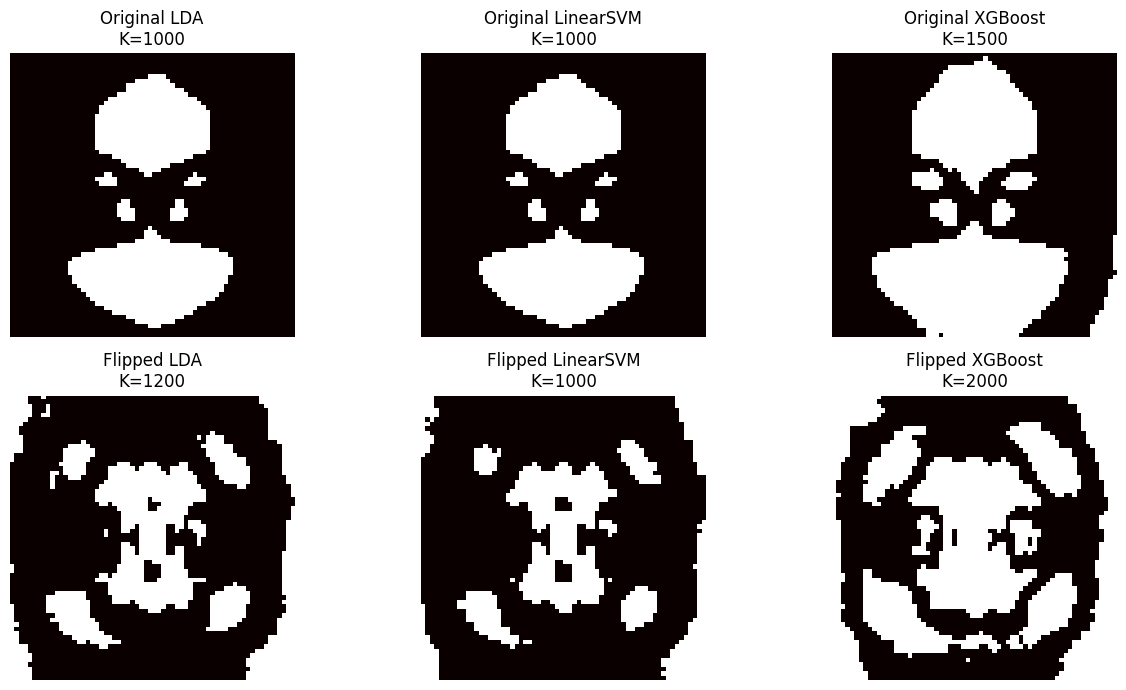

In [24]:
filter_flip_res = cv_select_k(X_train_flip, y_train_flip, seed=flip_seed)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, (name, res) in enumerate(filter_res.items()):
    axes[0, col].imshow(res["mask"].reshape(64, 64), cmap="hot")
    axes[0, col].set_title(f"Original {name}\nK={res['K_best']}")
    axes[0, col].axis("off")
    axes[1, col].imshow(filter_flip_res[name]["mask"].reshape(64, 64), cmap="hot")
    axes[1, col].set_title(f"Flipped {name}\nK={filter_flip_res[name]['K_best']}")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()

In [30]:
embed_flip_res, selected_pixels_flip = cv_lasso_embedded_fs(X_train_flip, y_train_flip, seed=flip_seed)

Number of selected pixels: 2836
Processing LDA...
Processing LinearSVM...
Processing XGBoost...


In [31]:
print("CV accuracy on the L1-selected pixels:")
for k, v in embed_flip_res.items():
    print(f"{k:12s}:{v['cv_acc']:.3f}")

CV accuracy on the L1-selected pixels:
LDA         :0.647
LinearSVM   :0.632
XGBoost     :0.837


In [32]:
selected_pixels_image_flip = np.zeros(X.shape[1])
selected_pixels_image_flip[selected_pixels_flip] = 1

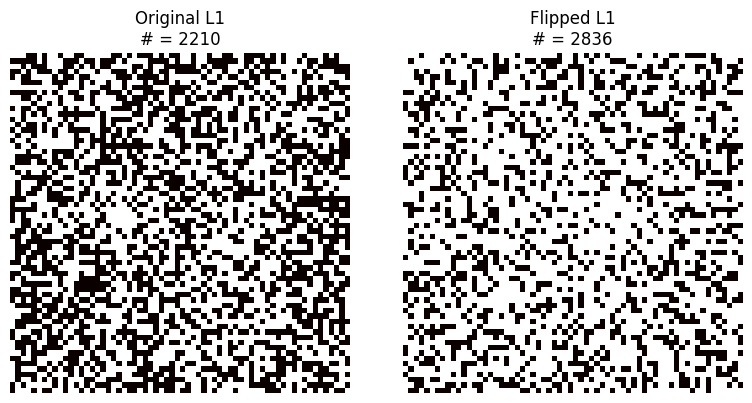

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(selected_pixels_image.reshape(64, 64), cmap="hot")
axes[0].set_title(f"Original L1\n# = {len(selected_pixels)}")
axes[0].axis("off")
axes[1].imshow(selected_pixels_image_flip.reshape(64, 64), cmap="hot")
axes[1].set_title(f"Flipped L1\n# = {len(selected_pixels_flip)}")
axes[1].axis("off")
plt.tight_layout()
plt.show()